In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable


In [44]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("desolution01/messy-employee-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\91801\.cache\kagglehub\datasets\desolution01\messy-employee-dataset\versions\1


In [45]:
#Checking the files inside 
import os
print(os.listdir(path))

['Messy_Employee_dataset.csv']


In [46]:
file_path = os.path.join(path, 'Messy_Employee_dataset.csv')
df = pd.read_csv(file_path)
df.head(10)

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
0,EMP1000,Bob,Davis,25.0,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True
1,EMP1001,Bob,Brown,NaN,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True
2,EMP1002,Alice,Jones,NaN,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True
3,EMP1003,Eva,Davis,25.0,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True
4,EMP1004,Frank,Williams,25.0,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False
5,EMP1005,Alice,Garcia,40.0,Sales-Texas,Inactive,6/10/2020,88642.84,alice.garcia@example.com,-5409003485,Good,False
6,EMP1006,Frank,Jones,NaN,Admin-Nevada,Active,4/3/2020,96288.43,frank.jones@example.com,-4518376063,Good,False
7,EMP1007,Bob,Jones,30.0,Cloud Tech-Florida,Inactive,7/17/2022,94497.91,bob.jones@example.com,-4134327559,Average,True
8,EMP1008,Frank,Davis,35.0,Admin-Nevada,Inactive,12/8/2023,115565.82,frank.davis@example.com,-4177656123,Excellent,True
9,EMP1009,Charlie,Johnson,NaN,DevOps-New York,Active,8/4/2022,76561.88,charlie.johnson@example.com,-8156985699,Excellent,True


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Employee_ID        1020 non-null   object 
 1   First_Name         1020 non-null   object 
 2   Last_Name          1020 non-null   object 
 3   Age                809 non-null    float64
 4   Department_Region  1020 non-null   object 
 5   Status             1020 non-null   object 
 6   Join_Date          1020 non-null   object 
 7   Salary             996 non-null    float64
 8   Email              1020 non-null   object 
 9   Phone              1020 non-null   int64  
 10  Performance_Score  1020 non-null   object 
 11  Remote_Work        1020 non-null   bool   
dtypes: bool(1), float64(2), int64(1), object(8)
memory usage: 88.8+ KB


In [48]:
print(f"The Number of rows = {df.shape[0]} & The Number of columns = {df.shape[1]}")

The Number of rows = 1020 & The Number of columns = 12


In [49]:
df.describe(include='all')

,Employee_ID,First_Name,Last_Name,Age,Department_Region,Status,Join_Date,Salary,Email,Phone,Performance_Score,Remote_Work
count,1020,1020,1020,809.000000,1020,1020,1020,996.000000,1020,1.020000e+03,1020,1020
unique,1020,8,8,NaN,36,3,760,NaN,64,NaN,4,2
top,EMP1000,Frank,Brown,NaN,HR-Florida,Pending,6/10/2024,NaN,grace.brown@example.com,NaN,Good,True
freq,1,142,148,NaN,41,356,5,NaN,27,NaN,270,513
mean,NaN,NaN,NaN,32.484549,NaN,NaN,NaN,85155.056396,NaN,-4.942253e+09,NaN,NaN
std,NaN,NaN,NaN,5.656860,NaN,NaN,NaN,19873.727918,NaN,2.817326e+09,NaN,NaN
min,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,50047.320000,NaN,-9.994973e+09,NaN,NaN
25%,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,68392.487500,NaN,-7.341992e+09,NaN,NaN
50%,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,85547.870000,NaN,-4.943997e+09,NaN,NaN
75%,NaN,NaN,NaN,40.000000,NaN,NaN,NaN,100974.027500,NaN,-2.520391e+09,NaN,NaN


In [50]:
df.isnull().sum()

Employee_ID            0
First_Name             0
Last_Name              0
Age                  211
Department_Region      0
Status                 0
Join_Date              0
Salary                24
Email                  0
Phone                  0
Performance_Score      0
Remote_Work            0
dtype: int64

In [51]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')

In [52]:
df.columns

Index(['employee_id', 'first_name', 'last_name', 'age', 'department_region',
       'status', 'join_date', 'salary', 'email', 'phone', 'performance_score',
       'remote_work'],
      dtype='object')

In [53]:
df['age'].value_counts()

age
40.0    210
25.0    206
30.0    205
35.0    188
Name: count, dtype: int64

In [54]:
df['age'].mean()

32.48454882571075

In [55]:
df['age'].median()

30.0

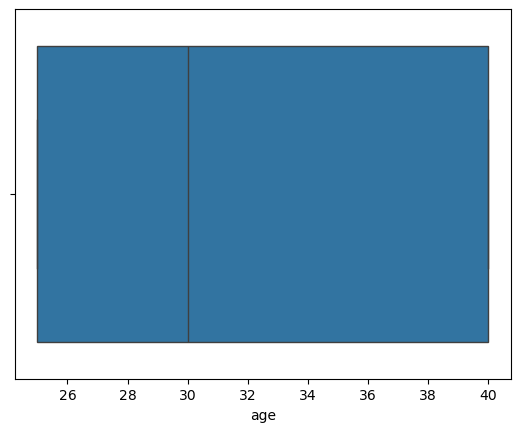

In [56]:
#For checking the outliers
sns.boxplot(x=df['age'])
plt.show()

In [57]:
df['age'] = df['age'].fillna(df['age'].median())

In [58]:
df.isnull().sum()

employee_id           0
first_name            0
last_name             0
age                   0
department_region     0
status                0
join_date             0
salary               24
email                 0
phone                 0
performance_score     0
remote_work           0
dtype: int64

In [59]:
df['age']=df['age'].astype(int)

In [60]:
labels = ['Young-Adult','Adult','Middle-Aged','Senior']
df['age_group'] = pd.qcut(df['age'], q=4, labels=labels[:3], duplicates='drop')


In [61]:
df[['age','age_group']].head(10)

,age,age_group
0,25,Young-Adult
1,30,Young-Adult
2,30,Young-Adult
3,25,Young-Adult
4,25,Young-Adult
5,40,Middle-Aged
6,30,Young-Adult
7,30,Young-Adult
8,35,Adult
9,30,Young-Adult


In [62]:
df.head(10)

,employee_id,first_name,last_name,age,department_region,status,join_date,salary,email,phone,performance_score,remote_work,age_group
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,Young-Adult
1,EMP1001,Bob,Brown,30,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Young-Adult
2,EMP1002,Alice,Jones,30,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True,Young-Adult
3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True,Young-Adult
4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False,Young-Adult
5,EMP1005,Alice,Garcia,40,Sales-Texas,Inactive,6/10/2020,88642.84,alice.garcia@example.com,-5409003485,Good,False,Middle-Aged
6,EMP1006,Frank,Jones,30,Admin-Nevada,Active,4/3/2020,96288.43,frank.jones@example.com,-4518376063,Good,False,Young-Adult
7,EMP1007,Bob,Jones,30,Cloud Tech-Florida,Inactive,7/17/2022,94497.91,bob.jones@example.com,-4134327559,Average,True,Young-Adult
8,EMP1008,Frank,Davis,35,Admin-Nevada,Inactive,12/8/2023,115565.82,frank.davis@example.com,-4177656123,Excellent,True,Adult
9,EMP1009,Charlie,Johnson,30,DevOps-New York,Active,8/4/2022,76561.88,charlie.johnson@example.com,-8156985699,Excellent,True,Young-Adult


In [63]:
df['salary'] = df['salary'].fillna(
    df.groupby('department_region')['salary'].transform('median')
)

In [64]:
df.isnull().sum()

employee_id          0
first_name           0
last_name            0
age                  0
department_region    0
status               0
join_date            0
salary               0
email                0
phone                0
performance_score    0
remote_work          0
age_group            0
dtype: int64

In [65]:
df.head()

,employee_id,first_name,last_name,age,department_region,status,join_date,salary,email,phone,performance_score,remote_work,age_group
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59767.65,bob.davis@example.com,-1651623197,Average,True,Young-Adult
1,EMP1001,Bob,Brown,30,Finance-Texas,Active,7/10/2020,65304.66,bob.brown@example.com,-1898471390,Excellent,True,Young-Adult
2,EMP1002,Alice,Jones,30,Admin-Nevada,Pending,12/7/2023,88145.90,alice.jones@example.com,-5596363211,Good,True,Young-Adult
3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,11/27/2021,69450.99,eva.davis@example.com,-3476490784,Good,True,Young-Adult
4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109324.61,frank.williams@example.com,-1586734256,Poor,False,Young-Adult


In [66]:
df[['department_region','salary']]

,department_region,salary
0,DevOps-California,59767.650
1,Finance-Texas,65304.660
2,Admin-Nevada,88145.900
3,Admin-Nevada,69450.990
4,Cloud Tech-Florida,109324.610
...,...,...
1015,HR-California,85969.535
1016,Cloud Tech-Texas,100215.060
1017,Finance-New York,114587.110
1018,HR-Florida,71318.790


In [67]:
df['salary'] = df['salary'].round().astype(int)

In [68]:
df['salary']

0        59768
1        65305
2        88146
3        69451
4       109325
         ...  
1015     85970
1016    100215
1017    114587
1018     71319
1019     77764
Name: salary, Length: 1020, dtype: int32

In [69]:
df = df.drop(['email', 'phone'], axis=1)


In [70]:
df.head(7)

,employee_id,first_name,last_name,age,department_region,status,join_date,salary,performance_score,remote_work,age_group
0,EMP1000,Bob,Davis,25,DevOps-California,Active,4/2/2021,59768,Average,True,Young-Adult
1,EMP1001,Bob,Brown,30,Finance-Texas,Active,7/10/2020,65305,Excellent,True,Young-Adult
2,EMP1002,Alice,Jones,30,Admin-Nevada,Pending,12/7/2023,88146,Good,True,Young-Adult
3,EMP1003,Eva,Davis,25,Admin-Nevada,Inactive,11/27/2021,69451,Good,True,Young-Adult
4,EMP1004,Frank,Williams,25,Cloud Tech-Florida,Active,1/5/2022,109325,Poor,False,Young-Adult
5,EMP1005,Alice,Garcia,40,Sales-Texas,Inactive,6/10/2020,88643,Good,False,Middle-Aged
6,EMP1006,Frank,Jones,30,Admin-Nevada,Active,4/3/2020,96288,Good,False,Young-Adult


# Which age group employees from which department-region have what type of performance score? 

C:\Users\91801\AppData\Local\Temp\ipykernel_19432\3881265973.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['department_region','age_group','performance_score'])
C:\Users\91801\AppData\Local\Temp\ipykernel_19432\3881265973.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_df.groupby(['department_region','age_group'])['count']


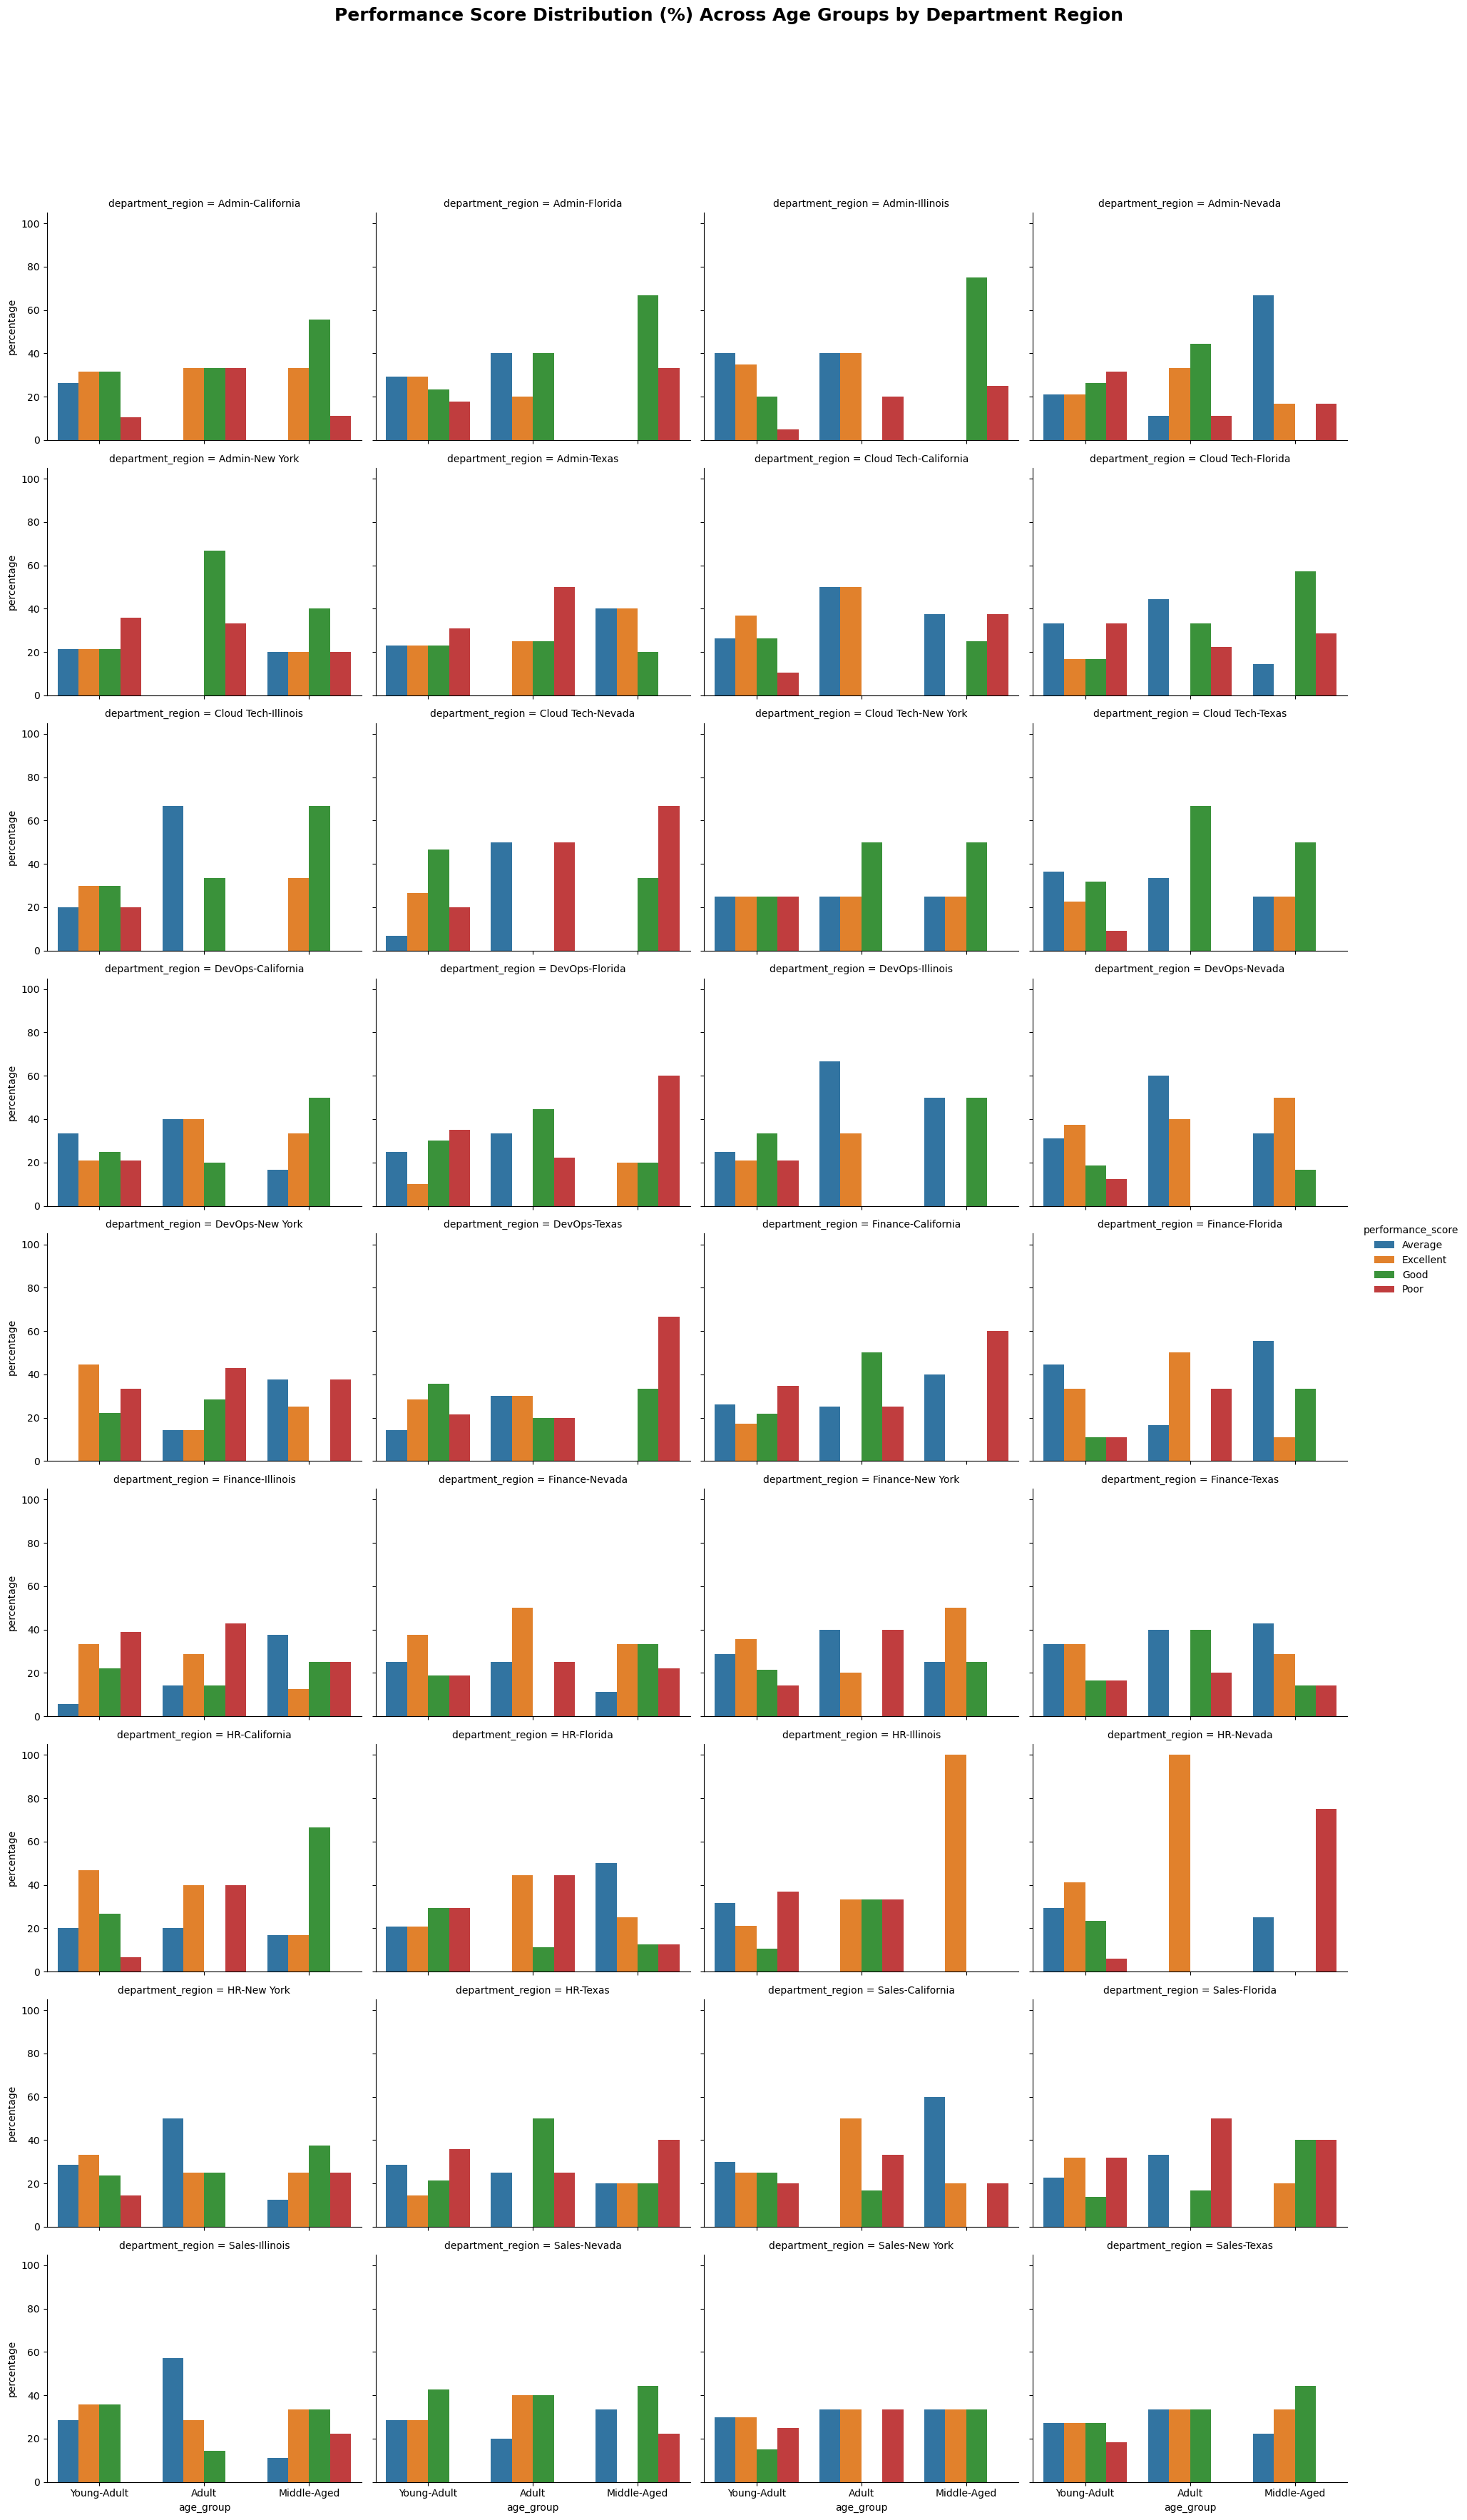

In [71]:
plot_df = (
    df.groupby(['department_region','age_group','performance_score'])
      .size()
      .reset_index(name='count')
)

plot_df['percentage'] = (
    plot_df.groupby(['department_region','age_group'])['count']
           .transform(lambda x: x/x.sum()*100)
)

g = sns.catplot(
    data=plot_df,
    x='age_group',
    y='percentage',
    hue='performance_score',
    col='department_region',
    kind='bar',
    col_wrap=4,
    height=4,
    aspect=1.2
)

g.fig.suptitle(
    'Performance Score Distribution (%) Across Age Groups by Department Region',
    fontsize=18,
    fontweight='bold'
)

plt.subplots_adjust(top=0.90)
plt.show()

# Which age group is giving the best performance and which is giving the poorest performance?

In [72]:
age_perf = pd.crosstab(
    df['age_group'],
    df['performance_score'],
    normalize='index'
) * 100

# Keep only Excellent and Poor
comparison = age_perf[['Excellent', 'Poor']]

print(comparison)

performance_score  Excellent       Poor
age_group                              
Young-Adult        28.135048  21.061093
Adult              25.531915  22.340426
Middle-Aged        20.952381  20.476190


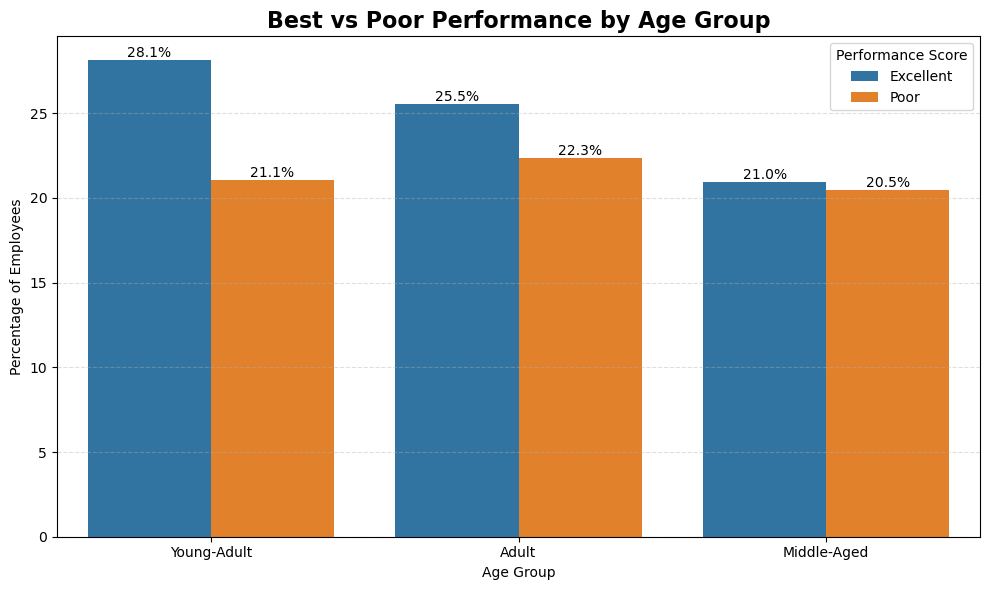

In [73]:
# Reset index for plotting
comparison = comparison.reset_index()

plt.figure(figsize=(10, 6))

comparison_melted = comparison.melt(
    id_vars='age_group',
    value_vars=['Excellent', 'Poor'],
    var_name='Performance',
    value_name='Percentage'
)

ax = sns.barplot(
    data=comparison_melted,
    x='age_group',
    y='Percentage',
    hue='Performance'
)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.title(
    'Best vs Poor Performance by Age Group',
    fontsize=16,
    fontweight='bold'
)
plt.xlabel('Age Group')
plt.ylabel('Percentage of Employees')
plt.legend(title='Performance Score')

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()

plt.show()

# Which department has what type of performance_score?

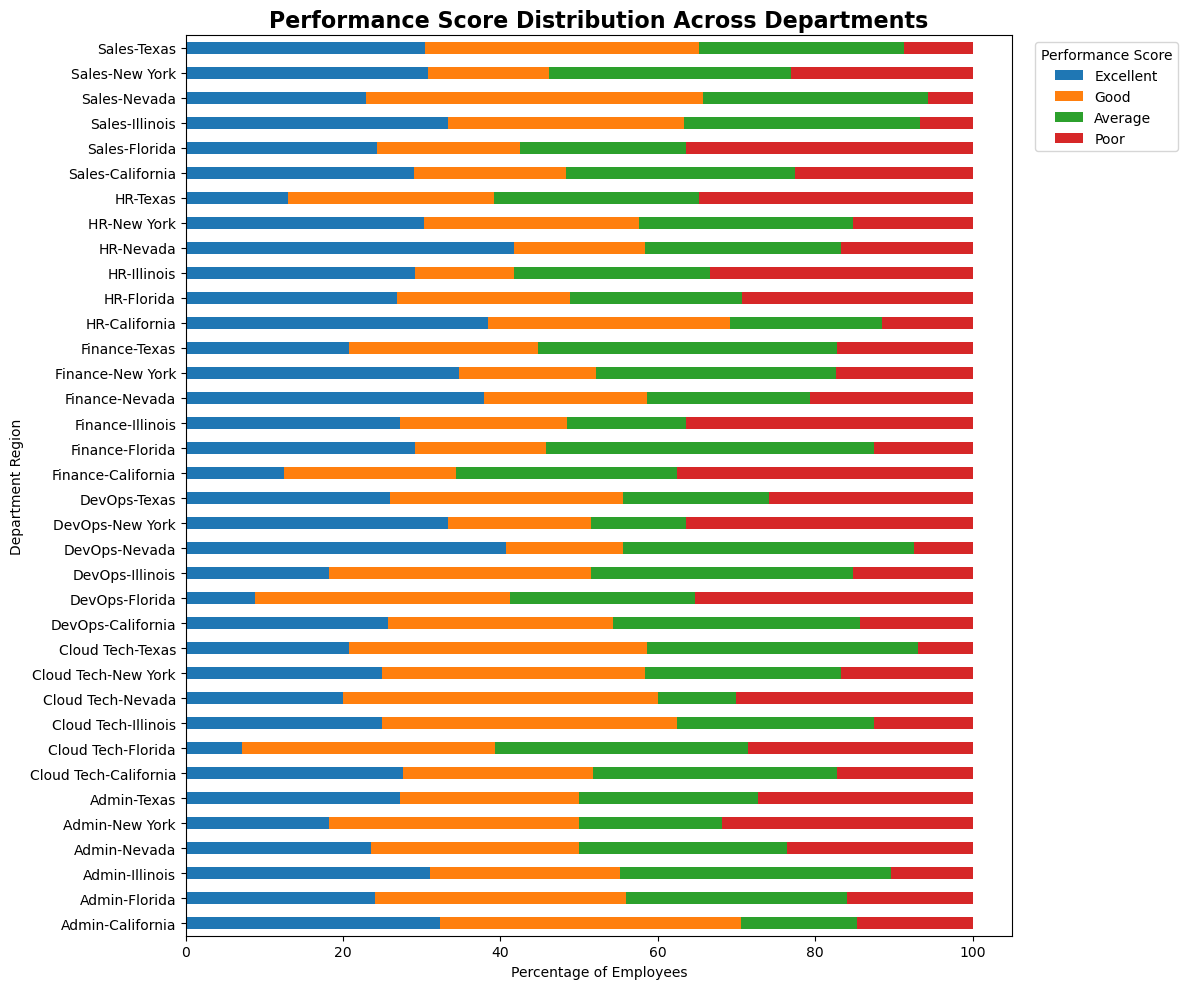

In [74]:
dept_perf = pd.crosstab(
    df['department_region'],
    df['performance_score'],
    normalize='index'
) * 100

# Order performance categories
dept_perf = dept_perf[['Excellent', 'Good', 'Average', 'Poor']]

# Plot
ax = dept_perf.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 10)
)

plt.title(
    'Performance Score Distribution Across Departments',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Percentage of Employees')
plt.ylabel('Department Region')

plt.legend(
    title='Performance Score',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

# Which department has what type of performance score and accordingly what salary employees receive?

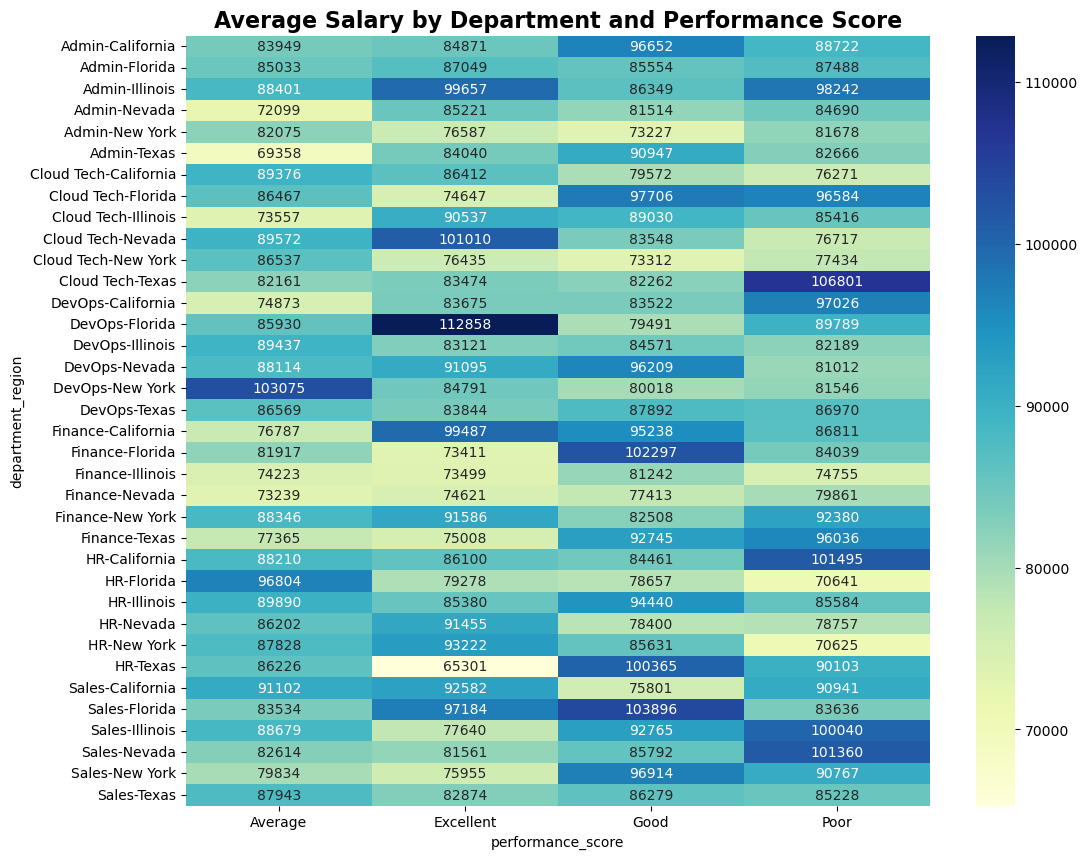

In [75]:
pivot = df.pivot_table(
    values='salary',
    index='department_region',
    columns='performance_score',
    aggfunc='mean'
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu'
)

plt.title(
    'Average Salary by Department and Performance Score',
    fontsize=16,
    fontweight='bold'
)

plt.show()

# Employees doing remote work — how are their performance scores and accordingly their salaries?

In [76]:
remote_perf_salary = df.pivot_table(
    values='salary',
    index='remote_work',
    columns='performance_score',
    aggfunc='mean'
)

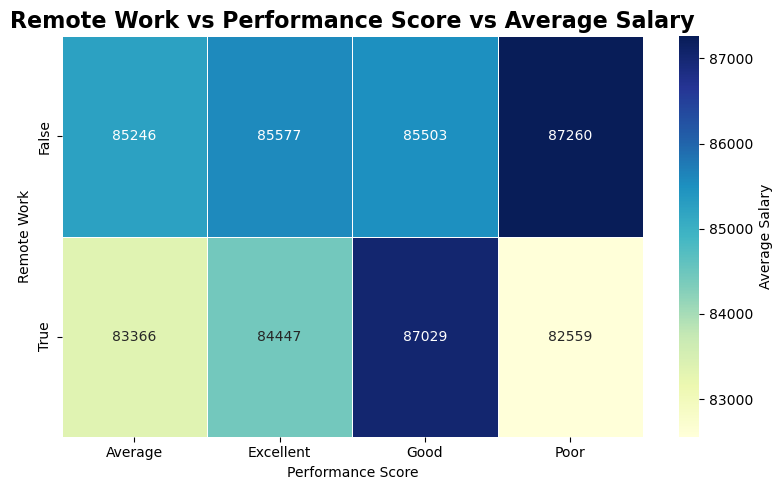

In [77]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    remote_perf_salary,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    linewidths=0.5,
    cbar_kws={'label': 'Average Salary'}
)

plt.title(
    'Remote Work vs Performance Score vs Average Salary',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Performance Score')
plt.ylabel('Remote Work')

plt.tight_layout()
plt.show()

# How many employees from each department are working remotely?

In [78]:
# print(remote_dept.head())
# print(remote_dept.columns)

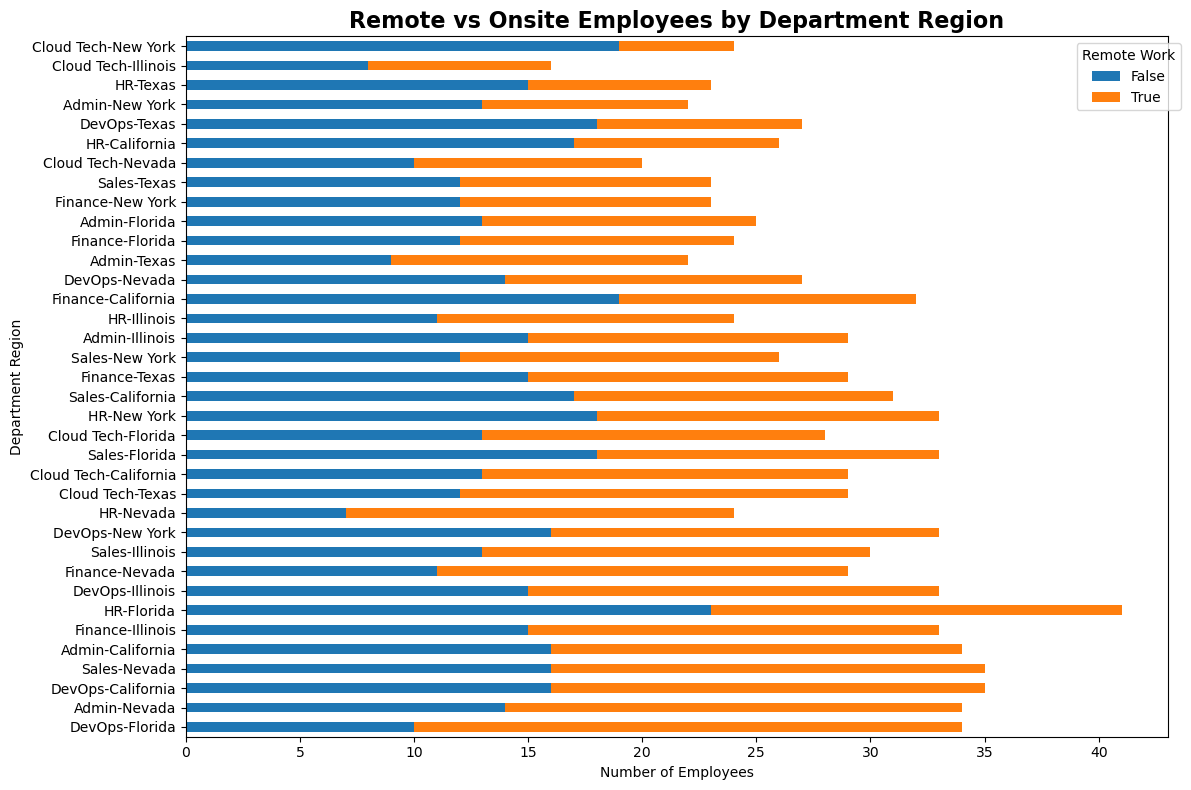

In [79]:
# Create count table
remote_dept = pd.crosstab(
    df['department_region'],
    df['remote_work']
)

# Sort by remote employees (True = Remote)
remote_dept = remote_dept.sort_values(
    by=True,
    ascending=False
)

# Plot
remote_dept.plot(
    kind='barh',
    stacked=True,
    figsize=(12, 8)
)

plt.title(
    'Remote vs Onsite Employees by Department Region',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Number of Employees')
plt.ylabel('Department Region')

plt.legend(
    title='Remote Work',
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()
plt.show()

In [80]:
!pip install psycopg2-binary sqlalchemy

Defaulting to user installation because normal site-packages is not writeable


In [81]:
from sqlalchemy import create_engine
username = "postgres"
passowrd = "030822"
host = "localhost"
port = "5432"
database = "messy_employee"

engine = create_engine(f"postgresql+psycopg2://{username}:{passowrd}@{host}:{port}/{database}")

In [82]:
table_name = "employee"
df.to_sql(table_name, engine, if_exists="replace", index=False)
print(f"Data has been successfully loaded into the table '{table_name}' in database '{database}'.")

Data has been successfully loaded into the table 'employee' in database 'messy_employee'.
